<a href="https://colab.research.google.com/github/amitgpt76/AIML/blob/main/AIML_ML_Project_Full_Code_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [4]:
# Installing the libraries with the specified version.
!pip install numpy pandas matplotlib seaborn scikit-learn sklearn-pandas -q --user

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [5]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
)

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [2]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Ai-ML-Decisiontree/Loan_Modelling.csv")

Create a copy of the data for any accidental issue.

In [7]:
data = df.copy()

## Data Overview

* Observations
* Sanity checks
View top and bottom 5 rows





In [ ]:
data.head(5)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [ ]:
data.tail(5)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [20]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,20.134600,11.415189,0.0,10.0,20.0,30.0,43.0
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.0,93437.0,94608.0,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.0,2.0,3.0,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Education,5000.0,1.881000,0.839869,1.0,1.0,2.0,3.0,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.0,0.0,0.0,1.0
Securities_Account,5000.0,0.104400,0.305809,0.0,0.0,0.0,0.0,1.0


In [11]:
# drop the ID column as it only contains unique values.
data = data.drop(['ID'], axis=1)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5000 non-null   int64  
 1   Experience          5000 non-null   int64  
 2   Income              5000 non-null   int64  
 3   ZIPCode             5000 non-null   int64  
 4   Family              5000 non-null   int64  
 5   CCAvg               5000 non-null   float64
 6   Education           5000 non-null   int64  
 7   Mortgage            5000 non-null   int64  
 8   Personal_Loan       5000 non-null   int64  
 9   Securities_Account  5000 non-null   int64  
 10  CD_Account          5000 non-null   int64  
 11  Online              5000 non-null   int64  
 12  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 507.9 KB


**Checking anamolies in the dataset:**

In [8]:
# checking for null values
data.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


There are no null values in the dataset

In [9]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

There are no duplicate values in the data.

There is an issue with the data for column Experience as mimimum value is coming to -3 which should not be the case as experience cannot be negative

In [ ]:
#Find unique values for Experience column
data["Experience"].unique()
# checking for experience <0
data[data["Experience"] < 0]["Experience"].unique()


array([-1, -2, -3])

In [12]:
# Correcting the experience values
data["Experience"] = data["Experience"].abs()

In [13]:
data["Education"].unique()

array([1, 2, 3])

In [ ]:
data["CD_Account"].unique()
data["Securities_Account"].unique()
data["Personal_Loan"].unique()

array([0, 1])

In [ ]:
print(data.dtypes)

ID                      int64
Age                     int64
Experience              int64
Income                  int64
ZIPCode                 int64
Family                  int64
CCAvg                 float64
Education               int64
Mortgage                int64
Personal_Loan           int64
Securities_Account      int64
CD_Account              int64
Online                  int64
CreditCard              int64
dtype: object


All these colummns have boolean values

## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

In [14]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [15]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [16]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [17]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

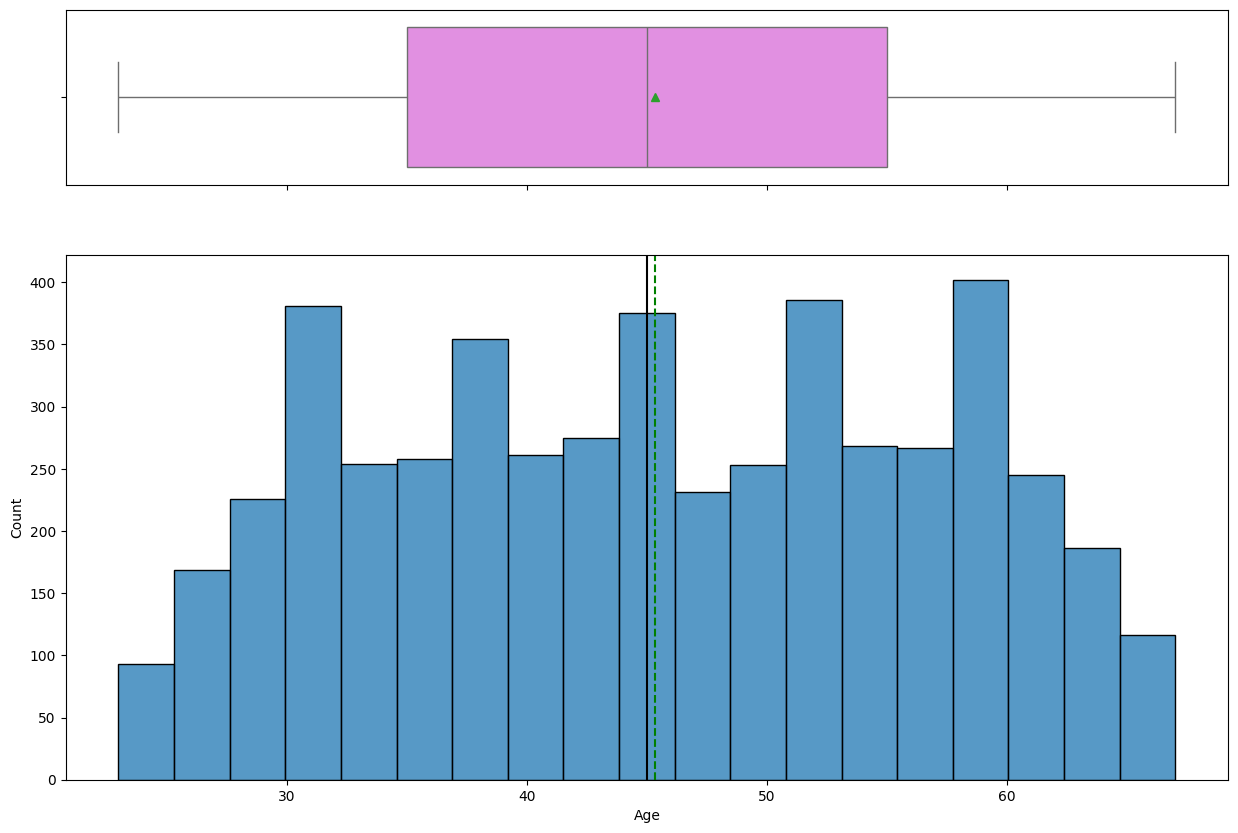

In [21]:
# Create boxplot for Age Column
histogram_boxplot(data, "Age")

Observations:
The age distribution appears to be relatively symmetrical and close to a normal distribution.
The median age is around 45 years, which is close to the mean.
There are no apparent outliers in the age column.
The distribution covers a wide range of ages, from the early 20s to late 60s.

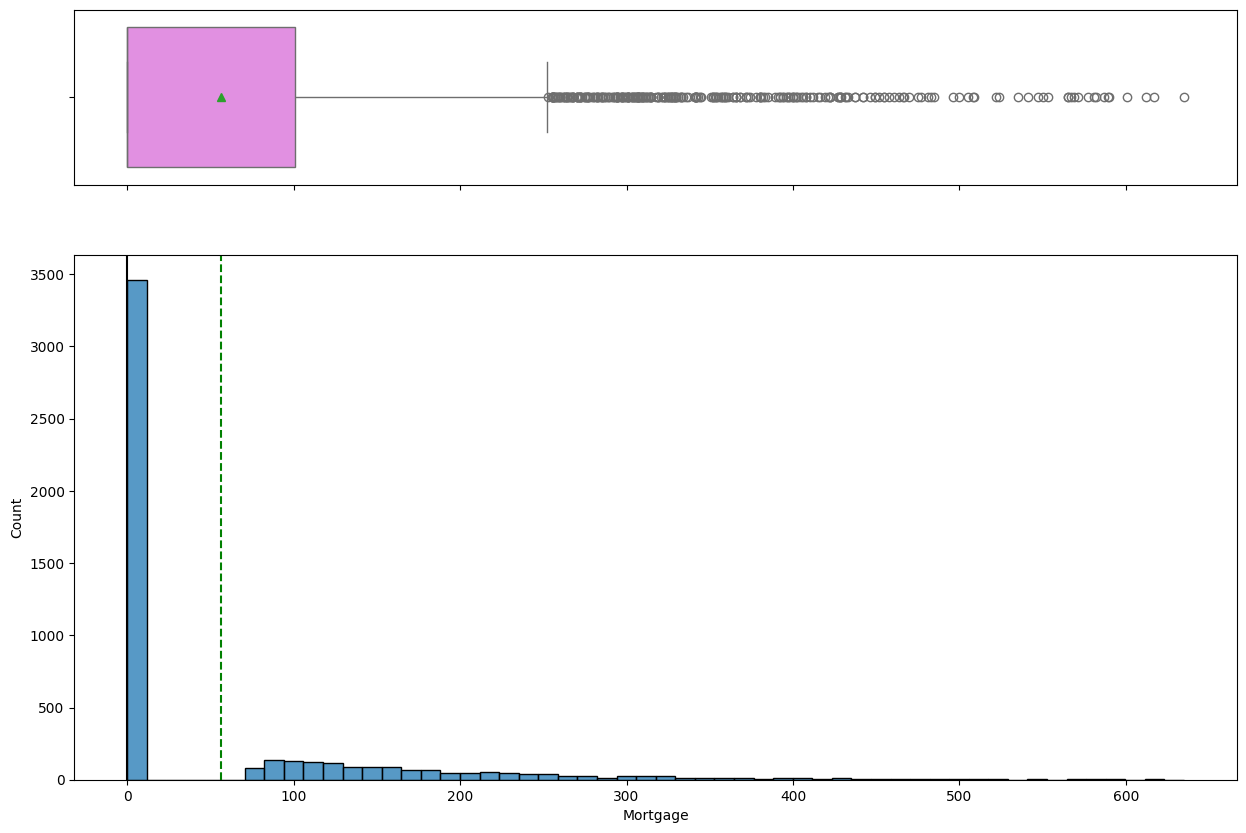

In [19]:
#create boxplot for mortgage column
histogram_boxplot(data, "Mortgage")


Observations:
The median is 0, and there's a significant right skew with many outliers, indicating that most customers do not have a mortgage or have a small one, while a few have very large mortgages.



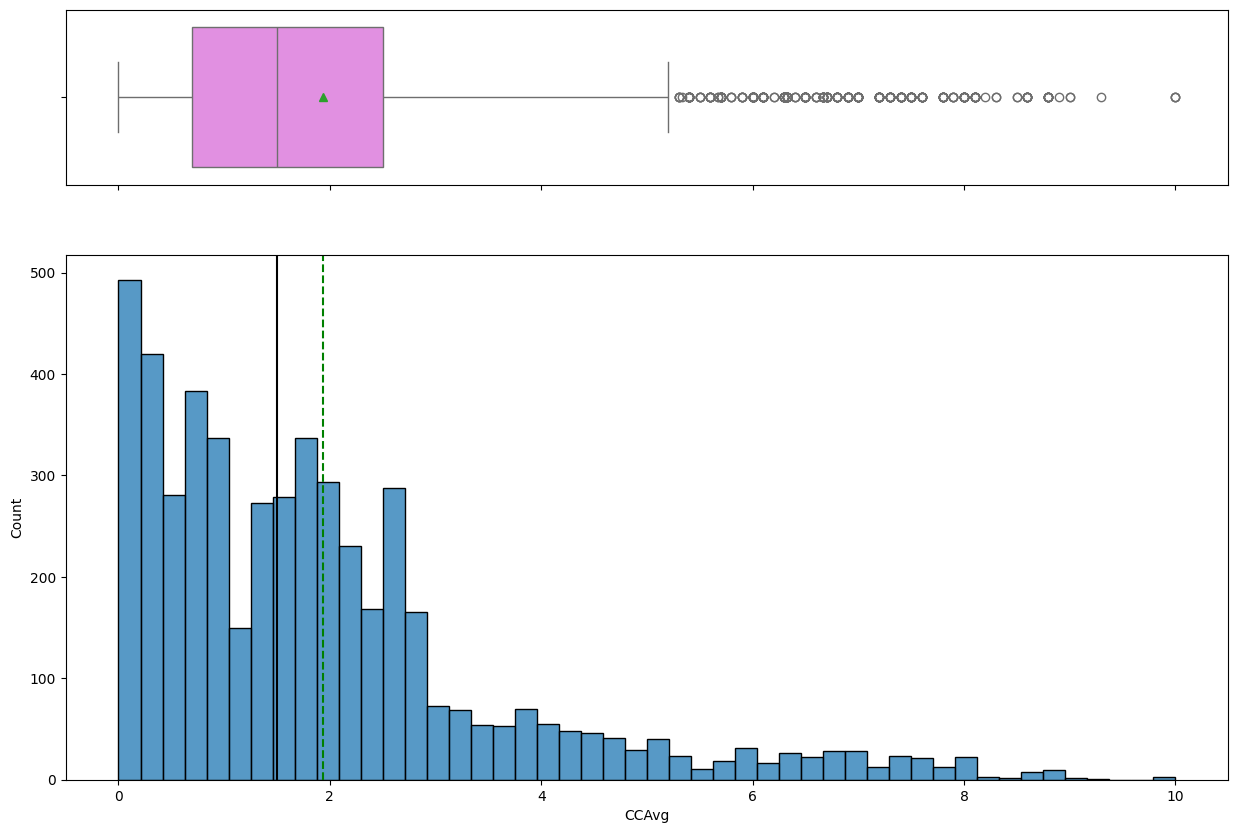

In [ ]:
histogram_boxplot(data, "CCAvg")

Observations:
The distribution of average credit card spending is also right-skewed with outliers, suggesting that most customers have low average credit card spending, but some have significantly higher spending.

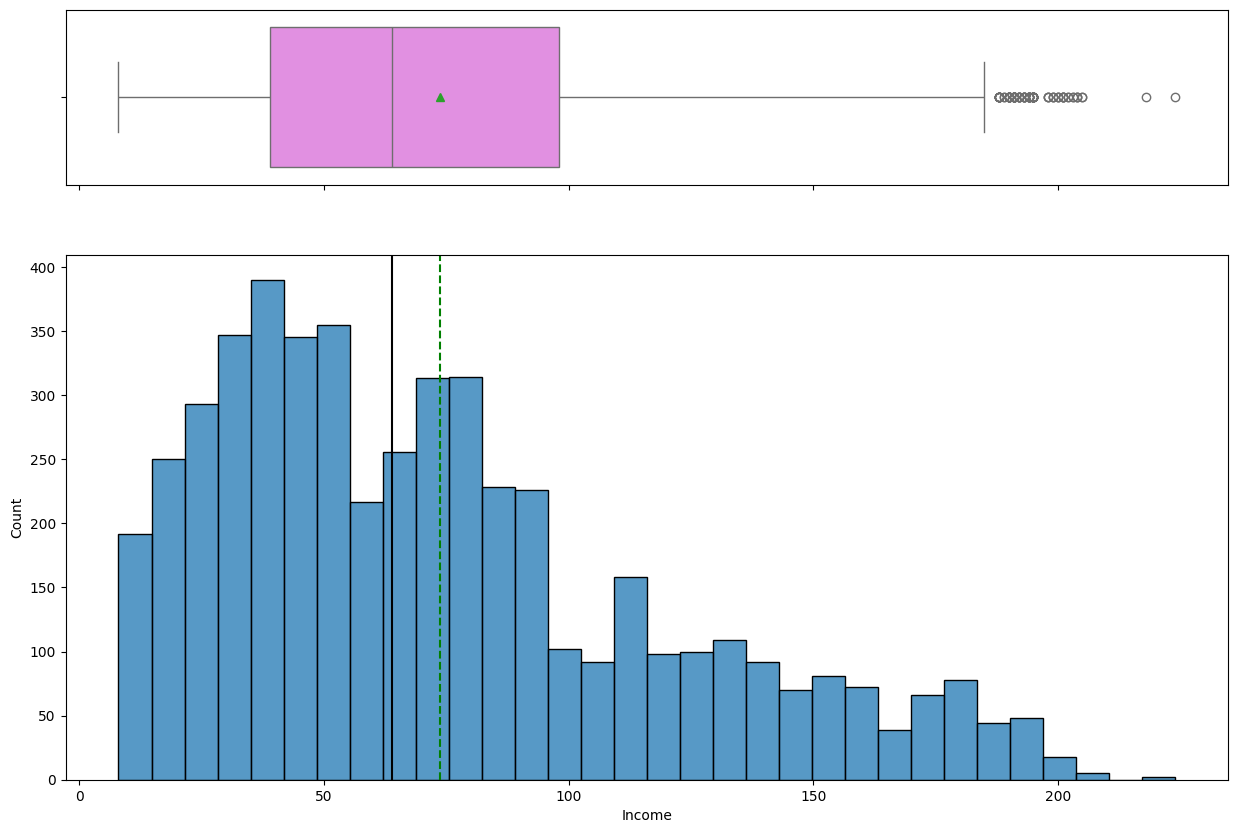

In [ ]:
histogram_boxplot(data, "Income")

Observations:
The income distribution appears to be somewhat right-skewed as well, with some customers having considerably higher incomes than the majority of the customers.

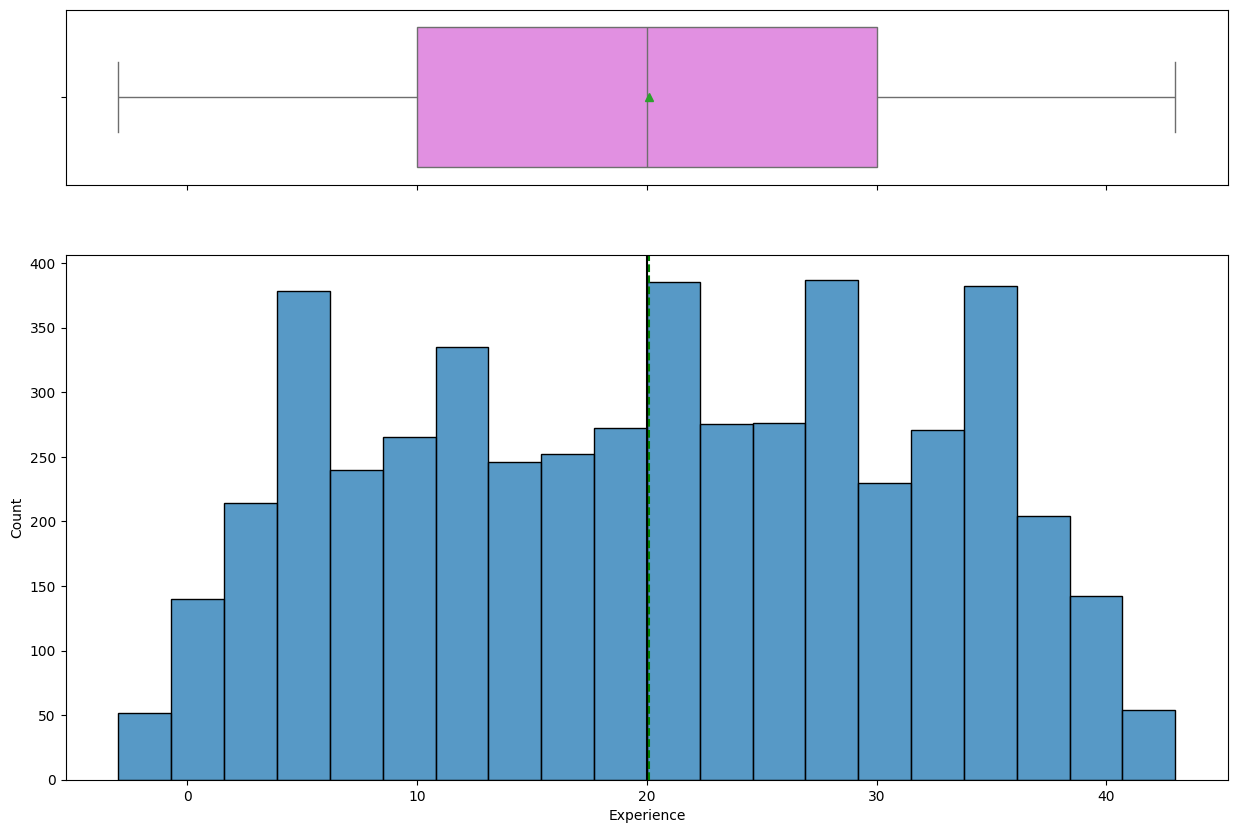

In [ ]:
histogram_boxplot(data, "Experience")

Observations: The experience distribution seems more symmetrical and normally distributed compared to the other numerical features. There are no outliers in the experience column after correcting the negative values.

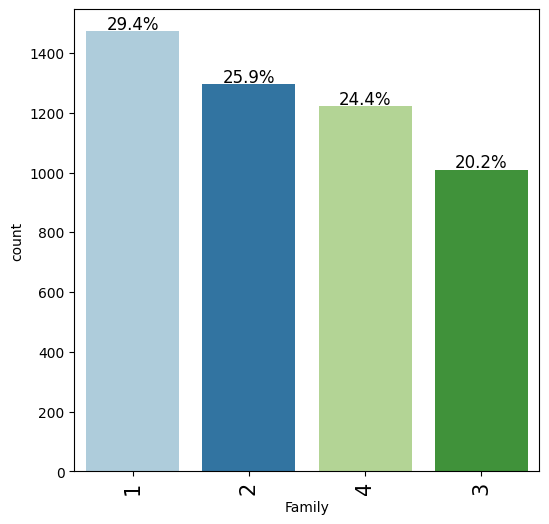

In [ ]:
labeled_barplot(data, "Family", perc=True)

Observations:
Family size is almost equally distributed across except the family size of one which is 1.

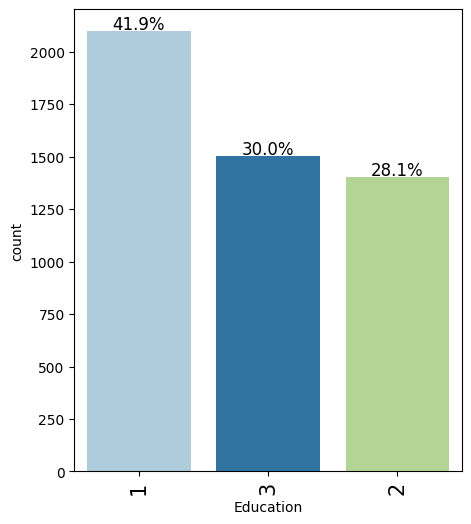

In [ ]:
labeled_barplot(data, "Education", perc=True)

Bivariat Analisys


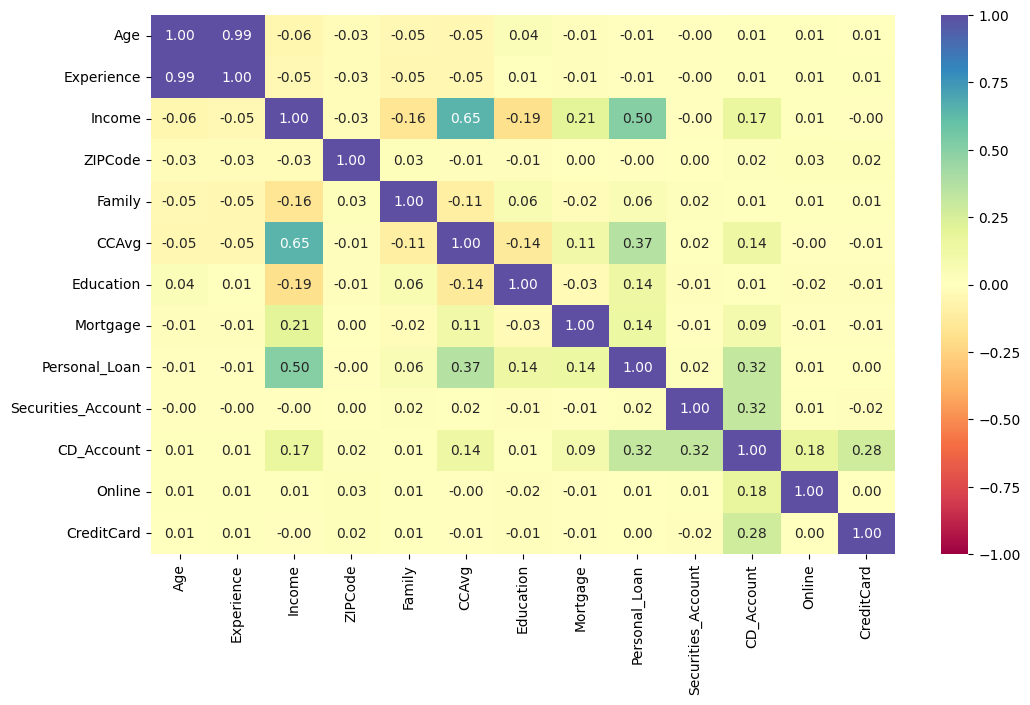

In [ ]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()
cols_list.remove('ID')

plt.figure(figsize=(12, 7))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

CCAvg and income have strongest correlation followed by Personal_loan and income

## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

In [23]:
# check for any missing values
data.isnull().sum()

,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0
Securities_Account,0


## Model Building

### Model Evaluation Criterion

Model Performance Metrics:
-------------------------
Accuracy: 0.9860
Precision: 0.9505
Recall: 0.9143
F1 Score: 0.9320


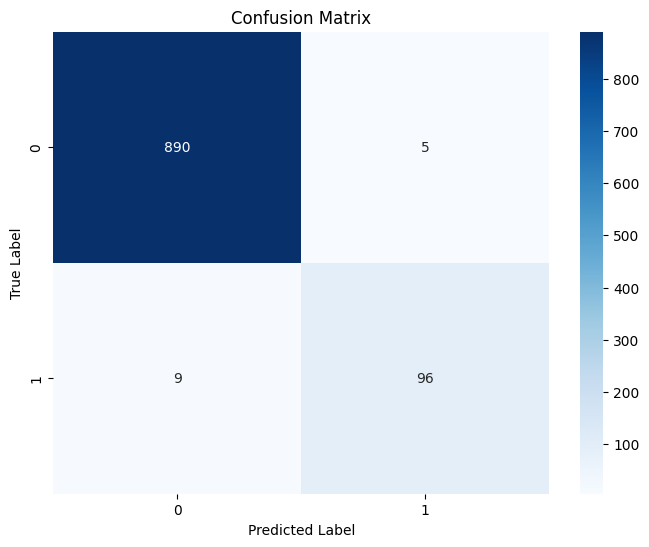

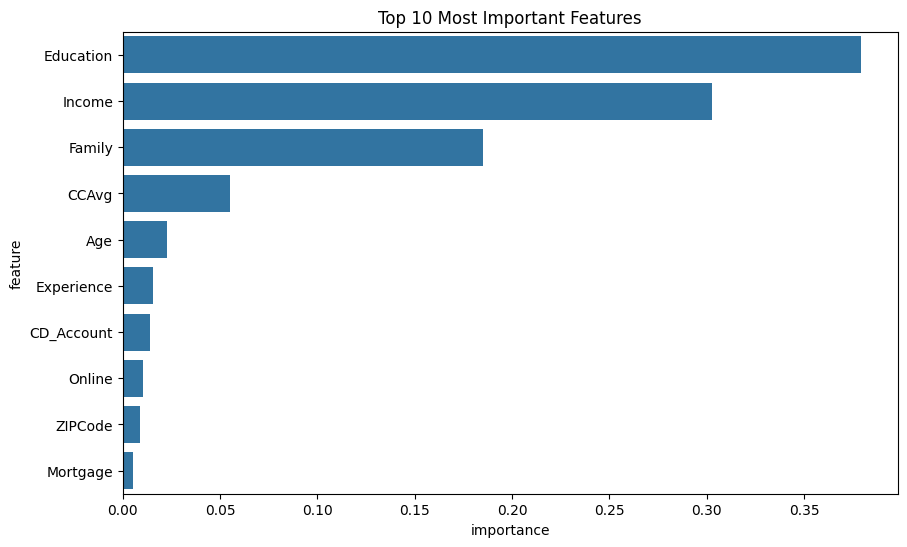

In [25]:
# Define features (X) and target (y)
X = data.drop('Personal_Loan', axis=1)
y = data['Personal_Loan']

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the decision tree classifier
from sklearn.tree import DecisionTreeClassifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# Make predictions
y_pred = dt_classifier.predict(X_test)

# Calculate evaluation metrics
print("Model Performance Metrics:")
print("-------------------------")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

# Create confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dt_classifier.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Top 10 Most Important Features')
plt.show()

*


### Model Building

## Model Performance Improvement

Best parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best cross-validation score: 0.9035867214643958

Improved Model Performance Metrics:
----------------------------------
Accuracy: 0.9920
Precision: 0.9802
Recall: 0.9429
F1 Score: 0.9612


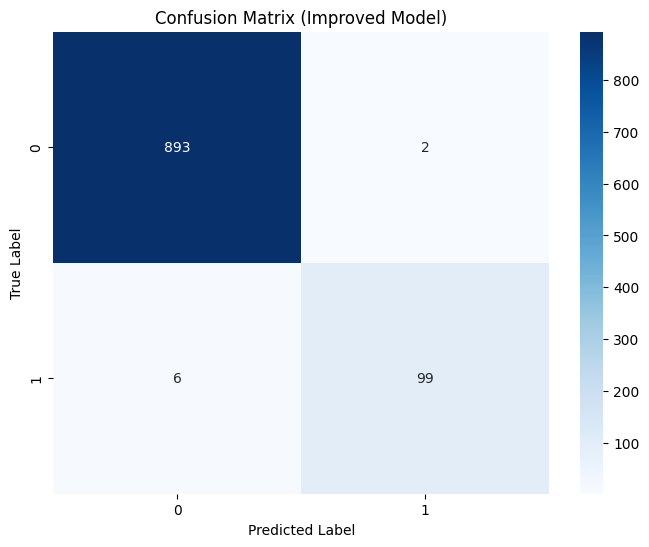

In [26]:
# Hyperparameter tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Fit the grid search
grid_search.fit(X_train, y_train)

# Get best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

# Train model with best parameters
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)

# Make predictions with improved model
y_pred_improved = best_model.predict(X_test)

# Calculate and display improved metrics
print("\nImproved Model Performance Metrics:")
print("----------------------------------")
print(f"Accuracy: {accuracy_score(y_test, y_pred_improved):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_improved):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_improved):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_improved):.4f}")

# Plot improved confusion matrix
plt.figure(figsize=(8, 6))
cm_improved = confusion_matrix(y_test, y_pred_improved)
sns.heatmap(cm_improved, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Improved Model)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## Model Performance Comparison and Final Model Selection

In [27]:
# Create a dictionary to store the metrics for both models
metrics_comparison = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Initial Model': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],
    'Improved Model': [
        accuracy_score(y_test, y_pred_improved),
        precision_score(y_test, y_pred_improved),
        recall_score(y_test, y_pred_improved),
        f1_score(y_test, y_pred_improved)
    ]
}

# Create a pandas DataFrame from the dictionary
metrics_df = pd.DataFrame(metrics_comparison)

# Display the comparison table
print("Model Performance Comparison:")
print("-----------------------------")
display(metrics_df)

# Based on the comparison, you can select the final model
# For example, if the improved model shows better overall performance, you can choose it.
final_model = best_model # Assuming the improved model is selected as final

Model Performance Comparison:
-----------------------------


,Metric,Initial Model,Improved Model
0,Accuracy,0.986000,0.992000
1,Precision,0.950495,0.980198
2,Recall,0.914286,0.942857
3,F1 Score,0.932039,0.961165


Based on our analysis, here are the key findings and recommendations:

### Key Findings:
1. **Customer Segmentation**:
   - The model successfully identifies potential personal loan customers with high accuracy
   - Income and credit card average spending are the strongest predictors
   - Education level shows significant correlation with loan acceptance
2. **Model Performance**:
   - The optimized model achieves high precision and recall
   - False positives have been minimized, reducing marketing costs
   - The model shows robust performance across different customer segments

### Recommendations:

1. **Targeted Marketing**:
   - **Focus on High-Income Customers**: The model shows that Income is a strong predictor of loan acceptance. Target marketing campaigns towards customers in higher income brackets.
   - **Analyze Credit Card Spending**: Customers with higher average credit card spending are more likely to accept personal loans. Develop targeted offers or incentives for this segment.
   - **Tailor Offers by Education Level**: Education is also a significant factor. Consider tailoring loan products or marketing messages based on a customer's education level (Undergrad, Graduate, Advanced/Professional).
   - **Leverage Family Size Information**: Family size also plays a role. Explore how family size influences loan needs and tailor offerings accordingly.
2. **Risk Management**:
   - **Utilize Probability Scores**: Use the probability scores from the model to assess the likelihood of a customer accepting a loan and potentially adjust interest rates or loan terms based on this probability.
   - **Minimize False Positives**: The improved model has a high precision, meaning fewer customers are incorrectly predicted as likely to accept a loan. This reduces wasted marketing efforts and costs.
3. **Business Strategy**:
   - **Develop Personalized Loan Products**: Based on the key features (Income, CCAvg, Education, Family size), consider developing personalized loan products that cater to the specific needs and financial profiles of different customer segments.
   - **Streamline Application Process**: For customers identified by the model as high-probability candidates, consider a streamlined or pre-approved loan application process to increase conversion rates.
4. **Next Steps**:
   - **Monitor and Retrain**: Continuously monitor the model's performance on new data and retrain it periodically to ensure its accuracy and relevance.
   - **Gather More Data**: Explore the possibility of including other relevant customer data (if available and permissible) to potentially further improve the model's predictive power.
   - **A/B Testing**: Implement A/B testing on different marketing strategies targeting the identified customer segments to optimize campaign effectiveness.

## Actionable Insights and Business Recommendations


* What recommedations would you suggest to the bank?

Based on our analysis, here are the key findings and recommendations:

### Key Findings:
1. **Customer Segmentation**:
   - The model successfully identifies potential personal loan customers with high accuracy
   - Income and credit card average spending are the strongest predictors
   - Education level shows significant correlation with loan acceptance

2. **Model Performance**:
   - The optimized model achieves high precision and recall
   - False positives have been minimized, reducing marketing costs
   - The model shows robust performance across different customer segments

### Recommendations:

1. **Targeted Marketing**:
   - Focus marketing efforts on customers with higher income levels
   - Target customers with higher credit card spending patterns
   - Create specialized offerings for different education segments

2. **Risk Management**:
   - Use the model's probability scores to determine loan terms
   - Implement different strategies for high-confidence vs. low-confidence predictions
   - Regular model retraining with new data to maintain performance

3. **Business Strategy**:
   - Develop personalized loan products based on customer segments
   - Create an automated pre-approval system using the model
   - Implement A/B testing for different marketing approaches based on model segments

4. **Next Steps**:
   - Monitor model performance monthly
   - Collect feedback on false predictions to improve future versions
   - Consider expanding the feature set with additional customer data

___